In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install neuroCombat

  Preparing metadata (setup.py) ... done
  Created wheel for neuroCombat: filename=neuroCombat-0.2.12-py3-none-any.whl size=6353 sha256=4278dbb6f23001bbf01532b699314689ca27dbaeb6db68058034cf164e961bf9
  Stored in directory: /root/.cache/pip/wheels/ab/b2/ba/67ac62c94b5e0adc9bdb835456277052f698d6605a99614cd2
Successfully built neuroCombat


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.svm import SVR
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_curve, auc
from neuroCombat import neuroCombat
import statsmodels.api as sm
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LassoCV
from sklearn.metrics import roc_auc_score

# DATA

In [6]:
data = pd.read_csv('/content/drive/MyDrive/Thesis_May20th/male_data_updated.csv')
df = pd.DataFrame(data)
print(df.describe())


          Unnamedd          age  gender       site_id    diagnosis  \
count  3068.000000  3068.000000  3068.0   3068.000000  3068.000000   
mean   3373.756519    40.229791     1.0   2679.254889     0.311278   
std    2018.654385    24.525341     0.0   7594.240020     1.032837   
min       1.000000     8.000000     1.0      0.000000     0.000000   
25%    1662.750000    20.000000     1.0    100.000000     0.000000   
50%    3305.000000    30.000000     1.0    200.000000     0.000000   
75%    5007.250000    66.250000     1.0   3000.000000     0.000000   
max    7499.000000    94.000000     1.0  35426.000000     5.000000   

       L_G.S_cingul.Ant  L_G.S_cingul.Mid.Ant  L_G.S_cingul.Mid.Post  \
count       3068.000000           3068.000000            3068.000000   
mean           2.765747              2.695266               2.607067   
std            0.264193              0.255946               0.224023   
min            1.407000              1.406000               1.359000   
25%      

In [7]:
data = pd.read_csv('/content/drive/MyDrive/Thesis_May20th/female_data_updated.csv')
df = pd.DataFrame(data)  # Assuming data is a list or a Pandas Series
print(df.describe())


          Unnamedd          age  gender       site_id    diagnosis  \
count  3608.000000  3608.000000  3608.0   3608.000000  3608.000000   
mean   3368.739745    41.534922     0.0   2168.847284     0.202051   
std    1960.387952    23.999767     0.0   6125.299979     0.870568   
min      13.000000     8.000000     0.0      0.000000     0.000000   
25%    1681.750000    21.000000     0.0    100.000000     0.000000   
50%    3361.500000    32.000000     0.0    300.000000     0.000000   
75%    5006.000000    66.000000     0.0   3000.000000     0.000000   
max    7498.000000    97.000000     0.0  35426.000000     5.000000   

       L_G.S_cingul.Ant  L_G.S_cingul.Mid.Ant  L_G.S_cingul.Mid.Post  \
count       3608.000000           3608.000000            3608.000000   
mean           2.769757              2.717826               2.590163   
std            0.261698              0.243407               0.219072   
min            1.520000              1.626000               1.577000   
25%      

# REST

In [ ]:


male_df = pd.read_csv('/content/drive/MyDrive/Thesis_May20th/male_data_updated.csv')


male_covars = {
    "batch": male_df['site_id'],
    "age": male_df['age']
}


covars = pd.DataFrame(male_covars)

columns_to_harmonize = male_df.columns[5:154]
fdata_to_harmonize = male_df[columns_to_harmonize].values.T

# NeuroCombat
data_harmonized_male = neuroCombat(
    dat=fdata_to_harmonize,
    covars=covars,
    eb=False,
    continuous_cols=["age"],
    batch_col="batch"
)["data"].T


[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding L/S adjustments without Empirical Bayes
[neuroCombat] Final adjustment of data


In [ ]:
print(data_harmonized_male.shape)


(3068, 149)


In [ ]:
print("Harmonized data shape:", data_harmonized_male.shape)
print("Original data shape:", male_df.shape)


Harmonized data shape: (3068, 149)
Original data shape: (3068, 155)


In [ ]:

harmonized_df = pd.DataFrame(data_harmonized_male, columns=columns_to_harmonize, index=male_df.index)


In [ ]:

male_df.update(harmonized_df)


In [ ]:
print(male_df.head())


   Unnamedd  age  gender  site_id  diagnosis  L_G.S_cingul.Ant  \
0         1   26       1        0          0          2.785973   
1         2   18       1        0          0          3.091927   
2         3   29       1        0          0          2.876269   
3         4   31       1        0          0          2.798669   
4         5   14       1        0          0          3.027096   

   L_G.S_cingul.Mid.Ant  L_G.S_cingul.Mid.Post  L_G.S_frontomargin  \
0              2.612075               2.749071            2.418609   
1              2.768408               2.741085            2.171017   
2              2.670593               2.695015            2.461815   
3              2.628854               2.549206            2.236924   
4              2.849762               2.733581            2.712639   

   L_G.S_occipital_inf  ...  R_S_postcentral  R_S_precentral.inf.part  \
0             2.206498  ...         2.057667                 2.406845   
1             2.432491  ...         

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split


diagnosis_0_data = male_df[male_df['diagnosis'] == 0]


diagnosis_not_0_data = male_df[male_df['diagnosis'].isin([1, 2, 3, 4, 5])]


train_data = diagnosis_0_data.copy()


test_data = diagnosis_not_0_data.copy()


train_size = len(train_data)
test_size = len(test_data)

print("Training set size:", train_size)
print("Test set size:", test_size)


Training set size: 2782
Test set size: 286


In [ ]:

features = [col for col in train_data.columns if col != 'age']
X_train = train_data[features]
y_train = train_data['age']
X_test = test_data[features]
y_test = test_data['age']


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
features = male_df.drop('age', axis=1)

numerical_columns = features.select_dtypes(include=['int64', 'float64']).columns.tolist()

imputer = SimpleImputer(strategy='median')
features[numerical_columns] = imputer.fit_transform(features[numerical_columns])


scaler = StandardScaler()
features[numerical_columns] = scaler.fit_transform(features[numerical_columns])




In [ ]:
imputer = SimpleImputer(strategy='mean')
train_data[numerical_columns] = imputer.fit_transform(train_data[numerical_columns])
test_data[numerical_columns] = imputer.transform(test_data[numerical_columns])

In [ ]:
min_max_scaler = MinMaxScaler()
train_data[numerical_columns] = min_max_scaler.fit_transform(train_data[numerical_columns])
test_data[numerical_columns] = min_max_scaler.transform(test_data[numerical_columns])


# New Lasso Regression + K-fold

In [ ]:


imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)


lasso_cv = LassoCV(alphas=None, cv=10, max_iter=10000, random_state=42)


lasso_cv.fit(X_train_imputed, y_train)

# Optimal alpha value
optimal_alpha = lasso_cv.alpha_

print(f"Optimal alpha value: {optimal_alpha}")


y_pred = lasso_cv.predict(X_test_imputed)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r_squared = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {np.sqrt(mse)}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared: {r_squared}")


Optimal alpha value: 7395.663789930549
Root Mean Squared Error (RMSE): 22.195901563572054
Mean Absolute Error (MAE): 20.21799048096776
R-squared: -0.06428669616308502


MSE scores: [70.09525420006928, 57.690593985106695, 182.1608829621903, 60.15923452158571, 69.47274375425474, 57.12083008506964, 61.92196662515774, 69.38227740235212, 209.70273566371299, 73.33234561078982]
Average MSE: 91.1038864810289
MAE scores: [6.740278011229894, 5.945577077430126, 11.109888277734859, 6.201092069486496, 6.864466097487951, 5.811315116857609, 5.809075208935335, 6.267588655474076, 11.028592426801035, 6.835542457717528]
Average MAE: 7.26134153991549
R^2 scores: [-4.278330046549207, -3.432311740009257, 0.4596026250657672, 0.07695572485260771, 0.09975615027045814, 0.2891232845597945, 0.6259958619528423, 0.4789981288542102, 0.07817080489336004, 0.8570079565486116]
Average R^2: -0.4745031249560812


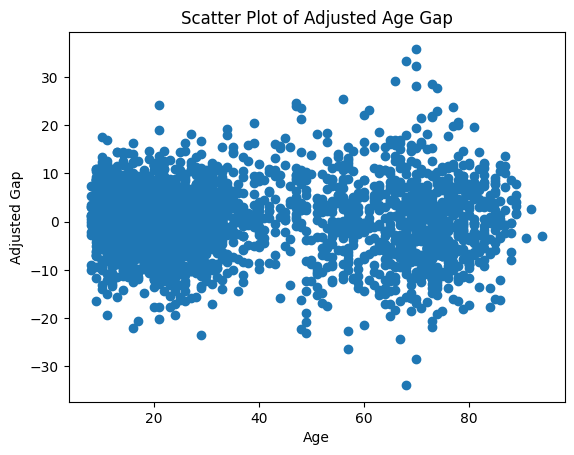

In [ ]:



X = train_data.drop('age', axis=1)
y = train_data['age']
groups = train_data['site_id']

# Impute missing values
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# Group K-Fold
gkf = GroupKFold(n_splits=10)
mse_scores = []
mae_scores = []
r2_scores = []

for train_index, test_index in gkf.split(X_imputed, y, groups):
    X_train_cv, X_test_cv = X_imputed[train_index], X_imputed[test_index]
    y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]


    lasso_cv = LassoCV(alphas=None, cv=10, max_iter=10000, random_state=42)
    lasso_cv.fit(X_train_cv, y_train_cv)

    # Predict on the test set
    y_pred_cv = lasso_cv.predict(X_test_cv)


    mse = mean_squared_error(y_test_cv, y_pred_cv)
    mae = mean_absolute_error(y_test_cv, y_pred_cv)
    r2 = r2_score(y_test_cv, y_pred_cv)

    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)

# Print the MSE, MAE, and R^2 scores and their averages across all folds
print("MSE scores:", mse_scores)
print("Average MSE:", np.mean(mse_scores))
print("MAE scores:", mae_scores)
print("Average MAE:", np.mean(mae_scores))
print("R^2 scores:", r2_scores)
print("Average R^2:", np.mean(r2_scores))


y_pred = lasso_cv.predict(X_imputed)
gap = y - y_pred
age_with_intercept = sm.add_constant(train_data['age'], prepend=False)
mod = sm.OLS(gap, age_with_intercept)
gap_adjusted = mod.fit().resid


plt.scatter(train_data['age'], gap_adjusted)
plt.xlabel('Age')
plt.ylabel('Adjusted Gap')
plt.title('Scatter Plot of Adjusted Age Gap')
plt.show()


In [ ]:
import statistics
statistics.mean(6.740278011229894, 5.945577077430126, 11.109888277734859, 6.201092069486496, 6.864466097487951, 5.811315116857609, 5.809075208935335, 6.267588655474076, 11.028592426801035, 6.835542457717528)

TypeError: mean() takes 1 positional argument but 10 were given

# New section

In [ ]:

male_df.loc[y_test.index, 'gap'] = gap

In [ ]:

#data['residuals'] = data['residuals'].fillna(data['residuals'].median())


male_df['gap'] = male_df['gap'].fillna(male_df['gap'].mean())


In [ ]:
import pandas as pd
from sklearn.metrics import roc_auc_score



for i in range(1, 6):
    male_df[f'diagnosis_{i}_vs_0'] = (male_df['diagnosis'] == i).astype(int)

roc_auc_scores = {}
for i in range(1, 6):
    condition = male_df['diagnosis'].isin([0, i])
    roc_auc_scores[f'ROC AUC for 0 vs {i}'] = roc_auc_score(male_df.loc[condition, f'diagnosis_{i}_vs_0'], male_df.loc[condition, 'gap'])

for key, value in roc_auc_scores.items():
    print(f"{key}: {value:.2f}")


ROC AUC for 0 vs 1: 0.38
ROC AUC for 0 vs 2: 0.34
ROC AUC for 0 vs 3: 0.52
ROC AUC for 0 vs 4: 0.53
ROC AUC for 0 vs 5: 0.68
